<a href="https://colab.research.google.com/github/lcbjrrr/algojust/blob/main/Pmpt05_Survivorship_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Survivorship bias

- **Survivorship bias**: Focusing only on data that "survived" a process while ignoring data that did not. This can lead to misinterpretations of cause and effect. For example, studying only successful entrepreneurs who dropped out of college without considering those who failed or those who succeeded with a college degree can lead to faulty conclusions about the necessity of a college degree
*The data used herein is for illustrative purposes only and does not reflect actual real-world data*

### Do you know this image? What is the issue/bias here?

![](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b2/Survivorship-bias.svg/1920px-Survivorship-bias.svg.png)

#### Explanation

During WWII, statisticians were tasked with determining which parts of military aircraft should be armored to better withstand enemy fire and reduce crashes. The initial approach was to reinforce areas that showed the most damage on returning planes.

However, a mathematician named Abraham Wald disagreed with this strategy. He argued that the returning planes represented the "survivors," and therefore, the damage they sustained was not critical enough to bring them down. Instead, Wald proposed that the areas undamaged on the returning planes were actually the most crucial, as damage to those parts likely resulted in the aircraft not making it back.

Wald's insight identified a logical error known as Survival Bias. This bias causes us to focus only on successful outcomes or "survivors" while overlooking failures or "non-survivors." The text explains that this bias is still prevalent today; for example, when analyzing business success, we often study companies that thrived while ignoring the many similar ventures that failed. Wald's idea highlighted the importance of considering the unseen failures (the planes that didn't return) to truly understand what was necessary for survival.

#### Can you read the results of a trained Decision [Tree](https://colab.research.google.com/github/lcbjrrr/quantai/blob/main/M4A_Py_ML_Arv.ipynb)? For the Titanic survival profile, would you survive?

![](https://pbs.twimg.com/media/G7IC23lWMAAppEG?format=png&name=small)

Download: [Titanic-females.csv](https://raw.githubusercontent.com/lcbjrrr/algojust/refs/heads/main/Titanic%20-%20females.csv)










#### What is wrong? Let's review the model training

> Read the file 'Titanic - females.csv' and show the dataframe

In [4]:
import pandas as pd
# Read the file 'Titanic - train.csv'
df_train = pd.read_csv('Titanic - females.csv')
# Show the dataframe
df_train.head()

,Female,Pclass,Age,FamilySize,Survived
0,True,1,31,0,True
1,True,2,34,1,True
2,True,1,36,1,True
3,True,2,28,0,True
4,True,1,37,2,True


> With this new dataframe, train a Decision Tree of depth 4 to learn to predict the Survived column based on Female,Pclass,Age,FamilySize. Then show the accuracy training score


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Define features (X) and target (y)
X = df_train[['Female', 'Pclass', 'Age', 'FamilySize']]
y = df_train['Survived']

# Initialize the Decision Tree Classifier with max_depth = 4
model = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the model
model.fit(X, y)

# Make predictions on the training data
y_pred = model.predict(X)

# Calculate and print the training accuracy score
accuracy = accuracy_score(y, y_pred)
print(f"Training Accuracy Score: {accuracy:.4f}")

Training Accuracy Score: 1.0000


> Show the visulization of the tree

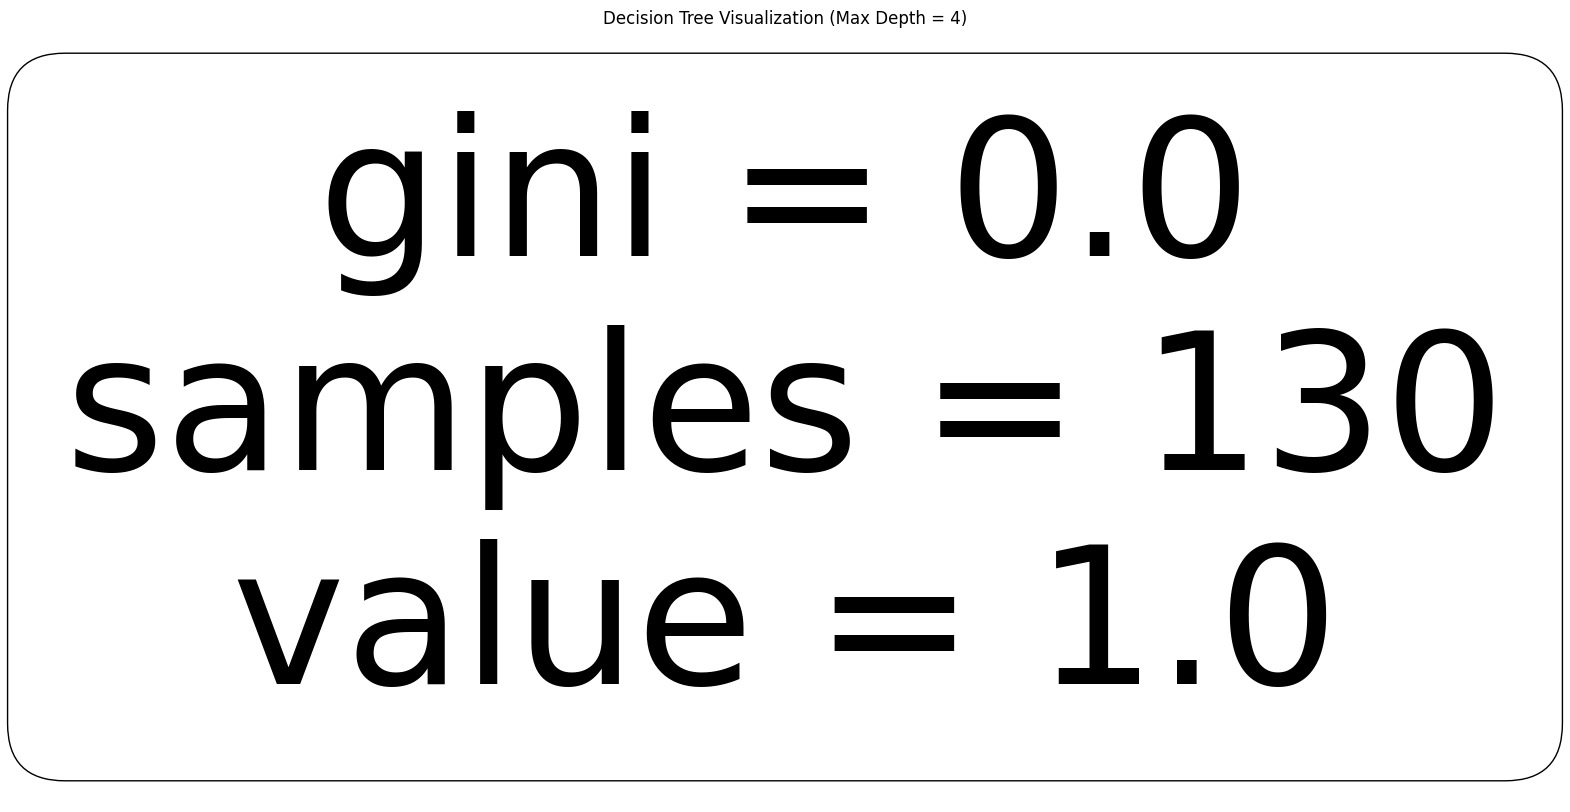

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns.tolist(), class_names=['Not Survived', 'Survived'], rounded=True)
plt.title('Decision Tree Visualization (Max Depth = 4)')
plt.show()

*This decision tree, trained on only female passengers, realizing that all of the ladies survided*



Download: [Titanic-test.csv](https://raw.githubusercontent.com/lcbjrrr/algojust/refs/heads/main/Titanic%20-%20test.csv)

>  Read the file 'Titanic - test.csv' and show the dataframe

In [7]:
import pandas as pd

# Read the file 'Titanic - test.csv'
df_test = pd.read_csv('Titanic - test.csv')

# Show the dataframe
print(df_test.head())

   Female  Pclass  Age  FamilySize  Survived
0    True       2   31           0      True
1    True       1   27           1      True
2    True       2   34           0      True
3   False       3   25           0     False
4    True       2   31           0      True


> Perform predictions for this testing dataset

In [8]:
# Extract features from the test dataset
X_test = df_test[['Female', 'Pclass', 'Age', 'FamilySize']]

# Perform predictions using the trained model
y_test_pred = model.predict(X_test)

# Display the first few predictions
print("First 10 predictions on the test set:")
print(y_test_pred[:10])

First 10 predictions on the test set:
[ True  True  True  True  True  True  True  True  True  True]


> Calculate the testing accuracy


In [9]:
y_test_true = df_test['Survived']
testing_accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"Testing Accuracy Score: {testing_accuracy:.4f}")

Testing Accuracy Score: 0.9000


*The initial predictions were flawed due to survivorship bias. The model was trained only on data of female passengers, which resulted in a biased model that predicted a very high survival rate (100% in one test) because the training data itself was skewed towards survivors. This led to inaccurate predictions when applied to a more diverse test set, as it didn't account for the non-survivors (e.g., male passengers) that were excluded from the training data*



### Let's re-train with the complete dataset

Download: [Titanic-train.csv](https://raw.githubusercontent.com/lcbjrrr/algojust/refs/heads/main/Titanic%20-%20train.csv)



> Train and show another tree for the original tranining dataset

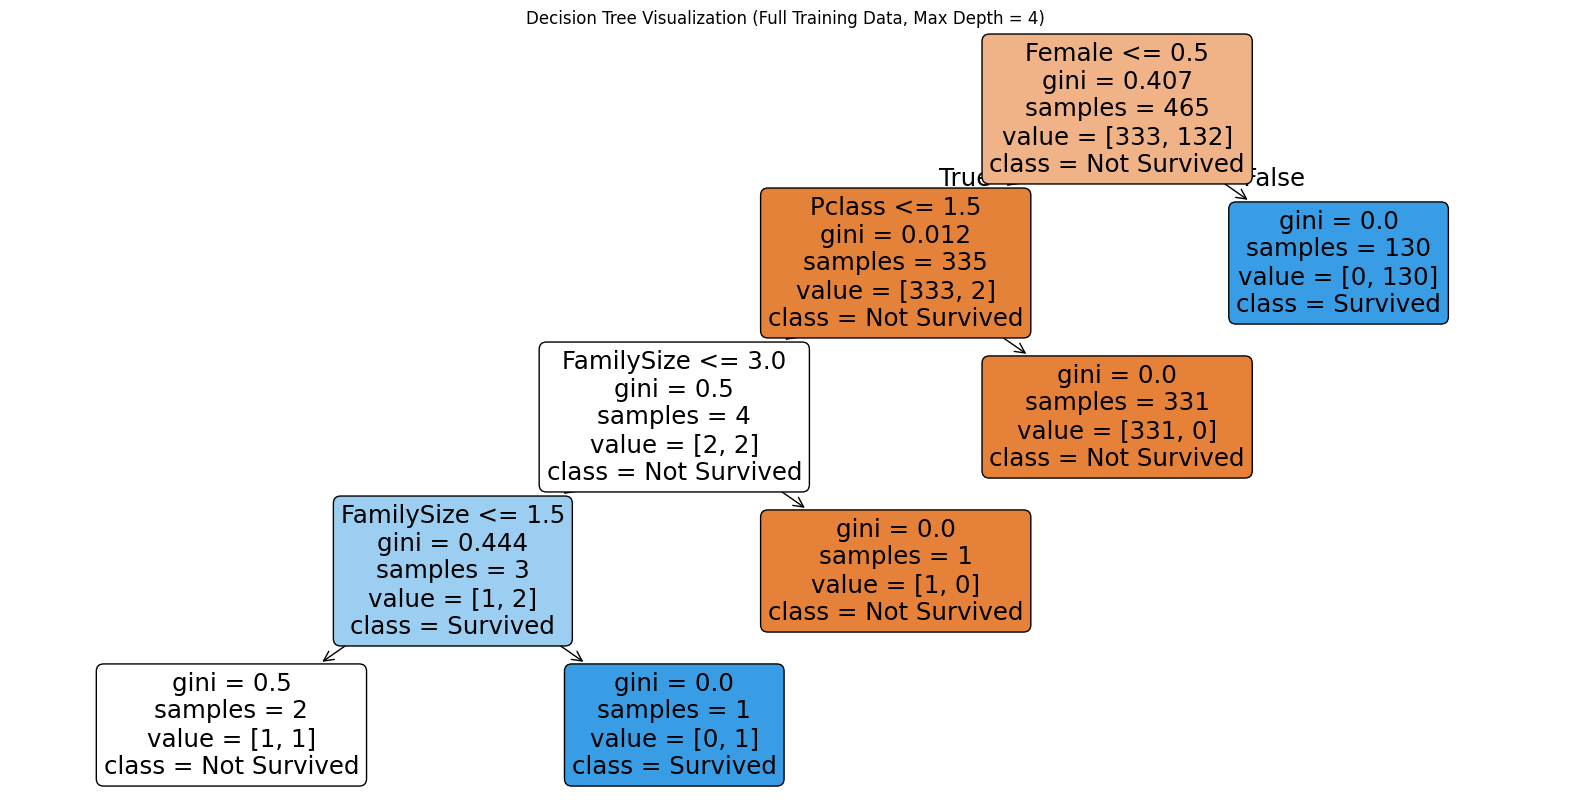

In [11]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Load the original full training dataset
df_full_train = pd.read_csv('Titanic - train.csv')

# Define features (X_full) and target (y_full) for the full dataset
X_full = df_full_train[['Female', 'Pclass', 'Age', 'FamilySize']]
y_full = df_full_train['Survived']

# Initialize and train a new Decision Tree Classifier with max_depth = 4
model_full = DecisionTreeClassifier(max_depth=4, random_state=42)
model_full.fit(X_full, y_full)

# Visualize the new Decision Tree
plt.figure(figsize=(20,10))
plot_tree(model_full, filled=True, feature_names=X_full.columns.tolist(), class_names=['Not Survived', 'Survived'], rounded=True)
plt.title('Decision Tree Visualization (Full Training Data, Max Depth = 4)')
plt.show()

![](https://pbs.twimg.com/media/HP8xgwyWAAA2nqD?format=jpg&name=medium)

*The decision tree for Titanic survival primarily indicates a strong influence of gender and passenger class (Pclass). For male passengers, young children in 1st or 2nd class had a high survival rate, while adult males in 1st or 2nd class mostly did not survive, and adult and elderly males in 3rd class had very low survival rates. Conversely, female passengers in 1st or 2nd class almost universally survived. For females in 3rd class, younger individuals had a higher chance of survival than older ones, though a significant portion still did not survive. Overall, being female and in a higher passenger class significantly increased the likelihood of survival*



> Perform predictions for this testing dataset on the new tree

In [12]:
# Extract features from the test dataset using the same columns as the training data
X_test_full = df_test[['Female', 'Pclass', 'Age', 'FamilySize']]

# Perform predictions using the new trained model (model_full)
y_test_pred_full = model_full.predict(X_test_full)

# Display the first few predictions
print("First 10 predictions on the test set using the full model:")
print(y_test_pred_full[:10])

First 10 predictions on the test set using the full model:
[ True  True  True False  True  True  True  True  True  True]


> Calculate the testing accuracy

In [13]:
from sklearn.metrics import accuracy_score

y_test_true = df_test['Survived']
testing_accuracy_full_model = accuracy_score(y_test_true, y_test_pred_full)
print(f"Testing Accuracy Score (Full Model): {testing_accuracy_full_model:.4f}")

Testing Accuracy Score (Full Model): 1.0000


*The testing accuracy is 1.0, which means the model achieved 100% accuracy on the test dataset. This indicates that the model predicted the survival outcome perfectly for all the individuals in the test set.*

## Activity: Survivorship bias





**Problem**

Survivorship bias can severely distort the insights gained from machine learning models by only considering data points that "survived" a particular process, neglecting critical information from those that did not. Your task is to select a dataset suitable for a classification problem (e.g., predicting customer churn, loan default, or student success) from Kaggle. .Train a classifier, such as a decision tree, on this dataset to make predictions. Analyze your model's performance and the characteristics of the data it was trained on. Specifically, reflect on: 1) are there missing data points or entire categories that were excluded because they didn't "survive" a particular outcome? 2) how might the absence of this "non-survivor" data lead to a biased or misleading understanding of the underlying patterns and predictions?

**Conclusion**

Summarize the specific instances of survivorship bias identified in your dataset and how they impacted your classifier's predictions and performance. Discuss the methods you employed to detect this bias and the feasibility or success of any proposed mitigation strategies. Reflect on the broader implications of survivorship bias in real-world applications of machine learning, emphasizing the importance of comprehensive data collection and critical data analysis to build more robust and equitable models.
"